In [ ]:
import numpy as np
import matplotlib.pyplot as plt 
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import MaxPooling2D,UpSampling2D,Conv2D,Input

In [2]:
Image_Size=(128,128)
Batch_Size=32
dataset=tf.keras.preprocessing.image_dataset_from_directory(
    "datasets/",
    image_size=Image_Size,
    batch_size=Batch_Size,
    shuffle=True
)

Found 70000 files belonging to 1 classes.


In [3]:
def normalize(images,labels):
    images=images/255.0
    return images
dataset=dataset.map(normalize)

In [4]:
noise_factor=0.3
def add_noise(images):
    noise_images=images+noise_factor*tf.random.normal(shape=tf.shape(images))
    noise_images=noise_images+tf.clip_by_value(noise_images,0.0,1.0)
    return noise_images,images
train_dataset=dataset.map(add_noise)

In [5]:
input_img=Input(shape=(128,128,3))
x=Conv2D(32,(3,3),activation='relu',padding='same')(input_img)
x=MaxPooling2D((2,2),padding="same")(x)
x=Conv2D(64,(3,3),activation='relu',padding='same')(x)
encoded=MaxPooling2D((2,2),padding='same')(x)

In [6]:
x=Conv2D(64,(3,3),activation='relu',padding='same')(encoded)
x=UpSampling2D((2,2))(x)
x=Conv2D(32,(3,3),activation='relu',padding='same')(x)
x=UpSampling2D((2,2))(x)
decoded=Conv2D(3,(3,3),activation='sigmoid',padding='same')(x)

autoencoder=Model(input_img,decoded)
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 128, 128, 3)    │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 75,651 (295.51 KB)

 Trainable params: 75,651 (295.51 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
autoencoder.compile(
    optimizer='adam',
    loss='mse'
)

In [8]:
history=autoencoder.fit(
    train_dataset,
    epochs=5
)

Epoch 1/5
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 532s 243ms/step - loss: 0.0017
Epoch 2/5
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 607s 277ms/step - loss: 3.8333e-04
Epoch 3/5
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 819s 374ms/step - loss: 3.4161e-04
Epoch 4/5
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 631s 288ms/step - loss: 3.1181e-04 
Epoch 5/5
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 651s 297ms/step - loss: 2.9236e-04 


In [11]:
for noisy_images,clean_images in train_dataset.take(1):
    reconstructed=autoencoder.predict(noisy_images)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.2435501..3.3966634].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.1718981..3.0102253].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.6186669..2.8178499].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0845714..3.03383].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.315292..2.9420009].


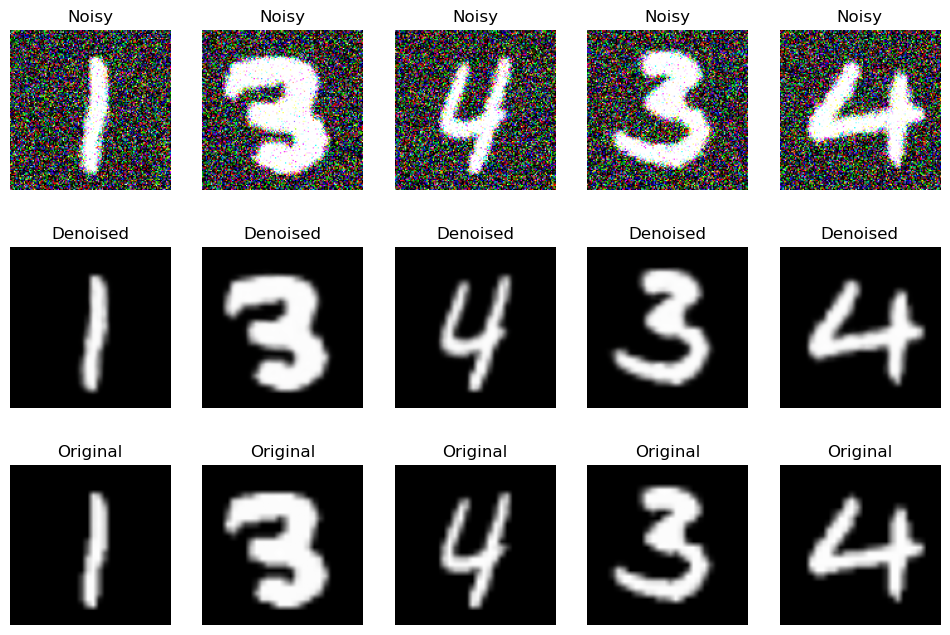

In [12]:
plt.figure(figsize=(12,8))

for i in range(5):
    plt.subplot(3,5,i+1)
    plt.imshow(noisy_images[i])
    plt.title('Noisy')
    plt.axis('off')

    plt.subplot(3,5,i+6)
    plt.imshow(reconstructed[i])
    plt.title('Denoised')
    plt.axis('off')

    plt.subplot(3,5,i+11)
    plt.imshow(clean_images[i])
    plt.title('Original')
    plt.axis('off')

plt.show()